# Caregiver Survey Response Screening

Four REDCap projects are screened here against one another: the verified caregiver
sample sets every limit, and the three recruitment samples are measured against it.

> **Note:** Screening rules identify responses that may need additional review. A triggered rule does not, by itself, prove that a response was submitted by a bot.


In [21]:
from pathlib import Path
import importlib

import matplotlib
matplotlib.use("agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

import bot_analysis as ba

ba = importlib.reload(ba)

%matplotlib inline
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 24)

project_dir = Path.cwd()
output_dir = project_dir / "Caregiver Outputs"
cache_dir = project_dir / "data_cache"

# ── Which studies are in scope ─────────────────────────────────────────────
# Read from config.yaml, so adding a token and a config block is all it takes
# to bring another study into every table below.
registry = ba.build_study_registry(project_dir)
display(Markdown(
    "**Studies in scope:** "
    + ", ".join(f"{s['label']} (pid {s['project_id']})" for s in registry.values())
))

# ── Load data (uses today's cached copy or pulls fresh) ─────────────────
source_table = ba.refresh_redcap_cache(project_dir, cache_dir)
audit_table = ba.check_redcap_audit_access(project_dir)

# ── Screening rules, recomputed for every study ────────────────────────────
screening_flags = ba.compute_screening_flags(project_dir, cache_dir)
rule_verification = ba.verify_flags_against_pipeline(screening_flags, output_dir)

# ── Build the canonical risk table, triage, and the final plan ─────────────
risk_table = ba.build_risk_table(output_dir, cache_dir, project_dir)
triaged = ba.build_review_triage(risk_table)
planned = ba.build_final_review_plan(triaged)

# ── Executive KPIs ──────────────────────────────────────────────────────
kpis = ba.build_stakeholder_executive_summary(triaged)

display(Markdown(f"""
| Metric | Count |
|--------|------:|
| Known-real caregiver responses | {kpis['verified_total']:,} |
| Recruited-sample responses | {kpis['online_total']:,} |
| Recruited responses cleared for payment | {kpis['pay_online']:,} |
| Recruited responses requiring review | {kpis['review_online']:,} |
| Recruited responses recommended not to pay | {kpis['reject_online']:,} |
| Known-real caregivers incorrectly refused (current policy) | {kpis['false_refusals']} |
"""))


**Studies in scope:** Study 1 - verified caregiver sample (pid 4797), Study 2 - online recruitment sample (pid 4581), Study 3 - bilingual sample (pid 5749), Study 4 - ICIS sample (pid 4931)


| Metric | Count |
|--------|------:|
| Known-real caregiver responses | 177 |
| Recruited-sample responses | 2,309 |
| Recruited responses cleared for payment | 448 |
| Recruited responses requiring review | 1,169 |
| Recruited responses recommended not to pay | 692 |
| Known-real caregivers incorrectly refused (current policy) | 3 |


---

## The Studies Being Screened

Every limit in this notebook is read off the verified caregiver sample. The other
three studies are measured against it, so the numbers stay comparable no matter
how many studies are added later.


In [22]:
# ── What each project number actually is ───────────────────────────────────
data_dictionary = ba.build_study_data_dictionary(project_dir, cache_dir)
display(data_dictionary.drop(columns=["Team notes"]))

# ── Did extending the rules to four studies change the old answers? ────────
display(Markdown("### Screening rules checked against the published pipeline"))
display(rule_verification)

if rule_verification.attrs["all_explained"]:
    widened = rule_verification[rule_verification["Match"].eq("Yes, scope widened")]
    if widened.empty:
        display(Markdown(
            "> Every rule reproduces the published pipeline exactly on the responses "
            "the pipeline covered. Extending the screening to four studies did not "
            "change a single earlier answer."
        ))
    else:
        display(Markdown(
            "> Every rule reproduces the published pipeline, except where its reach was "
            "deliberately widened: **"
            + ", ".join(widened["Rule"])
            + "**. No response the pipeline flagged has been unflagged."
        ))
else:
    raise RuntimeError("A screening rule disagrees with the published pipeline in a way that is not explained.")


,REDCap PID,Project name,Study,Role in the screening,Responses,First survey date,Last survey date,Responses with no recorded start time,Token in .env,Notes
0,4581,Infant Autism Screening (online recruitment sample),Study 2 - online recruitment sample,Screened recruitment sample,1779,2025-09-03,2025-09-06,0,TOKEN_DIRTY_4581,Nothing unusual.
1,4797,Infant Autism Screening (verified caregiver sample),Study 1 - verified caregiver sample,Reference - known-real caregivers,177,2025-09-29,2025-12-10,0,TOKEN_CLEAN_4797,Reference study. Every speed limit and burst window is read off the verified caregiver...
2,4931,Infant Autism Screening - ICIS,Study 4 - ICIS sample,Screened recruitment sample,10,2025-10-30,2025-11-05,0,TOKEN_ICIS_4931,Nothing unusual.
3,5749,Infant Autism Screening-27Sep25_bilingual-13Jul26,Study 3 - bilingual sample,Screened recruitment sample,520,2026-05-13,2026-09-16,449,TOKEN_BILINGUAL_5749,449 of 520 responses carry no survey start time. Responses imported from another proje...


### Screening rules checked against the published pipeline

,Rule,Responses compared,Published pipeline fired,This engine fired,Responses that disagree,Match,Note
0,R1,1956,283,283,0,Yes,Identical to the published pipeline
1,R2,1956,447,447,0,Yes,Identical to the published pipeline
2,R3,1956,846,846,0,Yes,Identical to the published pipeline
3,R4,1956,589,589,0,Yes,Identical to the published pipeline
4,R5,1956,0,0,0,Yes,Identical to the published pipeline
5,R6,1956,1682,1682,0,Yes,Identical to the published pipeline
6,R7,1956,17,17,0,Yes,Identical to the published pipeline
7,R8,1956,44,45,1,"Yes, scope widened","The branching audits now run on every study, not just the online recruitment study, so..."
8,R9,1956,2,2,0,Yes,Identical to the published pipeline


> Every rule reproduces the published pipeline, except where its reach was deliberately widened: **R8**. No response the pipeline flagged has been unflagged.

---

## The Bilingual Study Is Counted Once

The bilingual project asks every question twice, once in English and once in Spanish,
and gives the Spanish copy the same variable name with an `_s` on the end. A
respondent answers one language or the other, never both.

Left alone that would make the bilingual study look as though it had twice as many
questions as every other study, and would split one person's answers across two
columns where no rule could see them. Each Spanish variable is therefore folded back
onto its English twin before any rule runs: two questions in REDCap, one variable in
the screening, counted once.


In [23]:
# ── Every Spanish variable folded onto its English twin ────────────────────
bilingual_map = ba.build_bilingual_field_map(project_dir, cache_dir)
if bilingual_map.empty:
    display(Markdown("*No study in scope asks its questions in two languages.*"))
else:
    folded = bilingual_map[bilingual_map["How it was handled"].str.startswith("Merged")]
    carried = int(bilingual_map["Answers taken from the Spanish version"].sum())
    display(Markdown(
        f"**{len(folded):,} questions** were folded from Spanish onto their English twin, "
        f"carrying **{carried:,} answers** that would otherwise have sat in a column no rule reads."
    ))
    display(bilingual_map.head(12))

# ── Where the four surveys stop agreeing ───────────────────────────────────
study_differences = ba.build_study_differences(project_dir, cache_dir)
display(Markdown("### Differences between the four surveys"))
display(study_differences["Kind of difference"].value_counts().rename_axis(
    "Kind of difference").reset_index(name="Variables affected"))

renamed = study_differences[
    study_differences["Kind of difference"].eq("Same thing, different variable name")
]
if not renamed.empty:
    display(Markdown(
        "**The same thing under different names.** The screening looks for each of these "
        "under every name in turn, so no study is measured on a different question:"
    ))
    display(renamed[["Variable", "Studies that have it"]])


**328 questions** were folded from Spanish onto their English twin, carrying **1,042 answers** that would otherwise have sat in a column no rule reads.

,Study,REDCap PID,Spanish variable,Folded onto,How it was handled,Answers taken from the Spanish version
0,Study 3 - bilingual sample,5749,achievement_val_s,achievement_val,Merged into the English variable,11
1,Study 3 - bilingual sample,5749,age_confirm_elig_s,age_confirm_elig,Merged into the English variable,15
2,Study 3 - bilingual sample,5749,age_elig_s,age_elig,Merged into the English variable,26
3,Study 3 - bilingual sample,5749,benevolence_val_s,benevolence_val,Merged into the English variable,11
4,Study 3 - bilingual sample,5749,children_elig_s,children_elig,Merged into the English variable,26
5,Study 3 - bilingual sample,5749,conformity_val_s,conformity_val,Merged into the English variable,11
6,Study 3 - bilingual sample,5749,contact_coparent_s,contact_coparent,Merged into the English variable,0
7,Study 3 - bilingual sample,5749,contact_results_s___1,contact_results___1,Merged into the English variable,0
8,Study 3 - bilingual sample,5749,demo_area_s,demo_area,Merged into the English variable,4
9,Study 3 - bilingual sample,5749,demo_area_other_s,demo_area_other,Merged into the English variable,0


### Differences between the four surveys

,Kind of difference,Variables affected
0,Question is missing from some studies,28
1,Branching logic differs,2
2,"Same thing, different variable name",2


**The same thing under different names.** The screening looks for each of these under every name in turn, so no study is measured on a different question:

,Variable,Studies that have it
30,age_check_demo / age_confirm_elig,Study 1 - verified caregiver sample/Study 4 - ICIS sample uses age_check_demo; Study 2...
31,dob_child1,Study 1 - verified caregiver sample/Study 3 - bilingual sample/Study 4 - ICIS sample u...


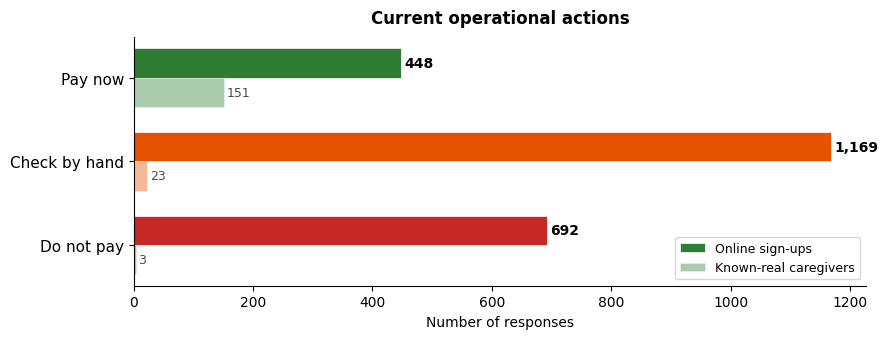

In [24]:
# ── Action summary chart ─────────────────────────────────────────────────
fig = ba.plot_stakeholder_action_summary(triaged)
plt.show()
plt.close(fig)

---

## How Screening Works

Every response is evaluated in three steps:

1. **Check against 14 screening signals.** Nine original rules (R1–R9) plus five supplemental checks (E1–E5).
2. **Each triggered signal adds points** according to its severity.
3. **The total score supports a payment or review recommendation.**

### Score formulas

Two scoring scales are carried side by side. Current operational decisions come from the operational scale unless stakeholders formally approve a different policy.

**Current operational score:**
> Serious rules × 2 + Mild rules × 1

**Proposed stakeholder score:**
> Serious rules × 5 + Mild rules × 1

### Current operational actions

| Operational score | Action |
|------------------:|--------|
| 0 | Pay now |
| 1–2 | Check by hand |
| 3 or more | Do not pay |

A `.edu` email address clears a held response, *unless* one of the contradiction checks fired (duplicate answer sheet, family contradiction, impossible demographics, or throwaway email).

In [25]:
# ── Compact rule key ─────────────────────────────────────────────────────
rule_key = ba.build_stakeholder_rule_key(triaged)
display(rule_key.style
    .set_caption("Screening rule reference")
    .apply(lambda row: [
        "background-color: #FFC7CE; color: #9C0006" if row["Severity"] == "Serious"
        else "background-color: #C6EFCE; color: #006100"
    ] * len(row), axis=1)
    .hide(axis="index"))

Code,Plain-language description,Category,Severity,Current operational points,Proposed stakeholder points,Known-real caregivers flagged,Online sign-ups flagged
R1,Whole survey finished faster than any verified caregiver,Survey timing,Serious,2,5,0,283
R2,Thoughts and feelings section faster than any verified caregiver,Survey timing,Serious,2,5,0,450
R3,One of the four sections finished below its own speed line,Survey timing,Mild,1,1,7,856
R4,The same answer repeated down a rating block,Response pattern,Mild,1,1,12,695
R5,Answer sheet identical to another response,Duplicate content,Serious,2,5,0,0
R6,Arrived within a minute of two or more other sign-ups,Arrival timing,Mild,1,1,6,1676
R7,Written comment nearly identical to another response,Duplicate content,Mild,1,1,0,24
R8,Family answers contradict each other,Family consistency,Serious,2,5,1,54
R9,Age and location cannot both be true,Demographics,Serious,2,5,2,10
E1,Whole survey time sits inside the uncertainty band,Survey timing,Mild,1,1,3,107


---

## Main Results

### Current action counts

,Recommended action,Verified caregivers,Online sign-ups,All responses,Share of all responses,What this means
0,Pay now,151,448,599,24.1%,No points. Send the gift card.
1,Check by hand,23,1169,1192,47.9%,One or two points. A person should look before paying.
2,Do not pay,3,692,695,28.0%,3 points or more. Refuse payment.


### Score distribution (current operational scale)

,Risk score,Verified caregivers,Online sign-ups,All responses,Recommended action
0,0,150,445,595,Pay now
1,1,18,776,794,Check by hand
2,2,6,395,401,Check by hand
3,3,2,158,160,Do not pay
4,4,1,109,110,Do not pay
5,5,0,116,116,Do not pay
6,6,0,187,187,Do not pay
7,7,0,115,115,Do not pay
8,8,0,5,5,Do not pay
9,9,0,3,3,Do not pay


### How often each screening signal fires

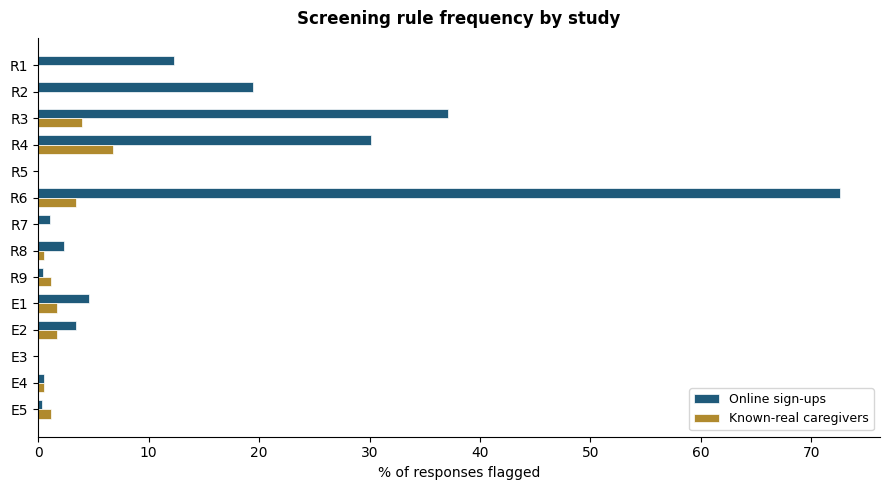

> **R6** fires on 73% of online sign-ups and 3% of known-real caregivers. A high study-level rate may reflect recruitment or data-collection conditions and should not automatically be interpreted as evidence against any individual response.

> **R6 (arrival timing)** is a contextual or channel-level signal. It describes the traffic pattern on a given day, not what an individual person did. It should not be described as conclusive evidence against an individual response.

In [26]:
# ── A. Current action counts for online sign-ups ────────────────────────
display(Markdown("### Current action counts"))
display(ba.build_action_summary_table(risk_table))

# ── B. Score distribution under the current operational scale ────────────
display(Markdown("### Score distribution (current operational scale)"))
display(ba.build_score_distribution_table(risk_table))

# ── C. Rule frequency by study ──────────────────────────────────────────
display(Markdown("### How often each screening signal fires"))
fig_freq = ba.plot_stakeholder_rule_frequency(triaged)
plt.show()
plt.close(fig_freq)

# Narrative interpretation of high-rate rules
high_rate = getattr(fig_freq, "_high_rate_rules", [])
if high_rate:
    for hr in high_rate:
        display(Markdown(
            f"> **{hr['code']}** fires on {hr['online_rate']:.0f}% of online sign-ups"
            f" and {hr['verified_rate']:.0f}% of known-real caregivers. "
            f"A high study-level rate may reflect recruitment or data-collection conditions "
            f"and should not automatically be interpreted as evidence against any individual response."
        ))

# Interpret the arrival-timing rule specifically
display(Markdown(
    "> **R6 (arrival timing)** is a contextual or channel-level signal. "
    "It describes the traffic pattern on a given day, not what an individual person did. "
    "It should not be described as conclusive evidence against an individual response."
))

---

## Record-Level Results

The table below shows the rules each response violated, the scores under both scales, and the current operational action. The complete table is in the exported workbook.

In [27]:
# ── Record-level results, every study ──────────────────────────────────────
records_sheet = ba.build_records_sheet(planned)
preview_columns = [c for c in records_sheet.columns if "email" not in c.lower()]

for study in records_sheet["Study"].unique():
    block = records_sheet[records_sheet["Study"].eq(study)]
    flagged = block[block["Final review plan"].ne(ba.FINAL_PAY)]
    display(Markdown(
        f"### {study} — {len(block):,} responses, {len(flagged):,} not cleared outright"
    ))
    display(block[preview_columns].head(6))

display(Markdown(
    f"**Complete table:** {len(records_sheet):,} responses across "
    f"{records_sheet['Study'].nunique()} studies. The full record is in the exported workbook."
))


### Study 1 - verified caregiver sample — 177 responses, 22 not cleared outright

,Study,REDCap PID,Record ID,Response key,Rules violated,"Rules violated, in plain language",Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Current operational score (Mild = 1, Serious = 2)",Score-based category,Final review plan,Include in Analysis,Responses sharing this address,Confirmation matches,Why no address,Can be paid,Arrived in a burst (R6),Survey finished,Sections timed,Why this final plan,"Proposed stakeholder score (Mild = 1, Serious = 5)"
0,Study 1 - verified caregiver sample,4797,18,4797-18,"R4, R6",The same answer repeated down a rating block; Arrived within a minute of two or more o...,2,0,2,2,Check by hand,Arrived in a Burst (R6),0,0,No address given,"The survey was never finished, so the address was never asked for",No,Yes,No,2,Arrived within the burst window of other sign-ups; decided as part of that cluster,2
1,Study 1 - verified caregiver sample,4797,40,4797-40,"R3, R6",One of the four sections finished below its own speed line; Arrived within a minute of...,2,0,2,2,Check by hand,Arrived in a Burst (R6),0,0,No address given,"The survey was never finished, so the address was never asked for",No,Yes,No,2,Arrived within the burst window of other sign-ups; decided as part of that cluster,2
2,Study 1 - verified caregiver sample,4797,14,4797-14,R6,Arrived within a minute of two or more other sign-ups,1,0,1,1,Pay now,Arrived in a Burst (R6),0,1,Yes,,Yes,Yes,Yes,4,Arrived within the burst window of other sign-ups; decided as part of that cluster,1
3,Study 1 - verified caregiver sample,4797,15,4797-15,R6,Arrived within a minute of two or more other sign-ups,1,0,1,1,Check by hand,Arrived in a Burst (R6),0,1,Yes,,Yes,Yes,Yes,4,Arrived within the burst window of other sign-ups; decided as part of that cluster,1
4,Study 1 - verified caregiver sample,4797,36,4797-36,R6,Arrived within a minute of two or more other sign-ups,1,0,1,1,Check by hand,Arrived in a Burst (R6),0,1,Yes,,Yes,Yes,Yes,4,Arrived within the burst window of other sign-ups; decided as part of that cluster,1
5,Study 1 - verified caregiver sample,4797,38,4797-38,R6,Arrived within a minute of two or more other sign-ups,1,0,1,1,Check by hand,Arrived in a Burst (R6),0,0,No address given,"The survey was never finished, so the address was never asked for",No,Yes,No,1,Arrived within the burst window of other sign-ups; decided as part of that cluster,1


### Study 2 - online recruitment sample — 1,779 responses, 1,698 not cleared outright

,Study,REDCap PID,Record ID,Response key,Rules violated,"Rules violated, in plain language",Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Current operational score (Mild = 1, Serious = 2)",Score-based category,Final review plan,Include in Analysis,Responses sharing this address,Confirmation matches,Why no address,Can be paid,Arrived in a burst (R6),Survey finished,Sections timed,Why this final plan,"Proposed stakeholder score (Mild = 1, Serious = 5)"
177,Study 2 - online recruitment sample,4581,1026,4581-1026,"R1, R2, R3, R4, R6, R8",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,3,3,9,Do not pay,Do Not Pay,0,1,Yes,,Yes,Yes,Yes,4,2 or more serious rules fired on this response's own evidence,18
178,Study 2 - online recruitment sample,4581,120,4581-120,"R1, R2, R3, R4, R6, R8",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,3,3,9,Do not pay,Do Not Pay,0,1,Yes,,Yes,Yes,Yes,4,2 or more serious rules fired on this response's own evidence,18
179,Study 2 - online recruitment sample,4581,571,4581-571,"R1, R2, R3, R4, R6, R8",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,3,3,9,Do not pay,Do Not Pay,0,1,Yes,,Yes,Yes,Yes,4,2 or more serious rules fired on this response's own evidence,18
180,Study 2 - online recruitment sample,4581,1119,4581-1119,"R1, R2, R3, R4, R6, R7",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,2,4,8,Do not pay,Do Not Pay,0,1,Yes,,Yes,Yes,Yes,4,2 or more serious rules fired on this response's own evidence,14
181,Study 2 - online recruitment sample,4581,1120,4581-1120,"R1, R2, R3, R4, R6, R7",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,2,4,8,Do not pay,Do Not Pay,0,1,Yes,,Yes,Yes,Yes,4,2 or more serious rules fired on this response's own evidence,14
182,Study 2 - online recruitment sample,4581,1330,4581-1330,"R1, R2, R3, R4, R6, R7",Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,2,4,8,Do not pay,Do Not Pay,0,1,Yes,,Yes,Yes,Yes,4,2 or more serious rules fired on this response's own evidence,14


### Study 3 - bilingual sample — 520 responses, 44 not cleared outright

,Study,REDCap PID,Record ID,Response key,Rules violated,"Rules violated, in plain language",Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Current operational score (Mild = 1, Serious = 2)",Score-based category,Final review plan,Include in Analysis,Responses sharing this address,Confirmation matches,Why no address,Can be paid,Arrived in a burst (R6),Survey finished,Sections timed,Why this final plan,"Proposed stakeholder score (Mild = 1, Serious = 5)"
1956,Study 3 - bilingual sample,5749,460,5749-460,"R2, R3, R4, R7",Thoughts and feelings section faster than any verified caregiver; One of the four sect...,4,1,3,5,Do not pay,Review by Hand,0,0,No address given,"The survey was never finished, so the address was never asked for",No,No,No,3,"A serious rule fired, describing a contradiction in what was answered. Pace cannot exp...",8
1957,Study 3 - bilingual sample,5749,461,5749-461,"R2, R3, R4, R7",Thoughts and feelings section faster than any verified caregiver; One of the four sect...,4,1,3,5,Do not pay,Review by Hand,0,0,No address given,"The survey was never finished, so the address was never asked for",No,No,No,3,"A serious rule fired, describing a contradiction in what was answered. Pace cannot exp...",8
1958,Study 3 - bilingual sample,5749,463,5749-463,"R2, R3, R4",Thoughts and feelings section faster than any verified caregiver; One of the four sect...,3,1,2,4,Do not pay,Review by Hand,0,0,No address given,"The survey was never finished, so the address was never asked for",No,No,No,3,"A serious rule fired, describing a contradiction in what was answered. Pace cannot exp...",7
1959,Study 3 - bilingual sample,5749,470,5749-470,"R4, R8, E4",The same answer repeated down a rating block; Family answers contradict each other; No...,3,1,2,4,Do not pay,Review by Hand,0,0,No address given,The survey was finished but no address was given,No,No,Yes,4,"A serious rule fired, describing a contradiction in what was answered. Pace cannot exp...",7
1960,Study 3 - bilingual sample,5749,233,5749-233,"R7, R9",Written comment nearly identical to another response; Age and location cannot both be ...,2,1,1,3,Do not pay,Review by Hand,0,1,Yes,,Yes,No,Yes,0,"A serious rule fired, describing a contradiction in what was answered. Pace cannot exp...",6
1961,Study 3 - bilingual sample,5749,264,5749-264,"R4, R9",The same answer repeated down a rating block; Age and location cannot both be true,2,1,1,3,Do not pay,Review by Hand,0,1,Yes,,Yes,No,Yes,0,"A serious rule fired, describing a contradiction in what was answered. Pace cannot exp...",6


### Study 4 - ICIS sample — 10 responses, 5 not cleared outright

,Study,REDCap PID,Record ID,Response key,Rules violated,"Rules violated, in plain language",Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Current operational score (Mild = 1, Serious = 2)",Score-based category,Final review plan,Include in Analysis,Responses sharing this address,Confirmation matches,Why no address,Can be paid,Arrived in a burst (R6),Survey finished,Sections timed,Why this final plan,"Proposed stakeholder score (Mild = 1, Serious = 5)"
2476,Study 4 - ICIS sample,4931,9,4931-9,"R3, E1, E2",One of the four sections finished below its own speed line; Whole survey time sits ins...,3,0,3,3,Do not pay,Review by Hand,0,1,Yes,,Yes,No,Yes,4,"Rules fired that describe what this person answered, and the response was not slower t...",3
2477,Study 4 - ICIS sample,4931,6,4931-6,R8,Family answers contradict each other,1,1,0,2,Check by hand,Review by Hand,0,1,Yes,,Yes,No,Yes,4,"A serious rule fired, describing a contradiction in what was answered. Pace cannot exp...",5
2478,Study 4 - ICIS sample,4931,3,4931-3,R4,The same answer repeated down a rating block,1,0,1,1,Check by hand,Review by Hand,0,1,Yes,,Yes,No,Yes,4,"Rules fired that describe what this person answered, and the response was not slower t...",1
2479,Study 4 - ICIS sample,4931,5,4931-5,E5,Started between midnight and five in the morning,1,0,1,1,Check by hand,Review by Hand,0,0,No address given,"The survey was never finished, so the address was never asked for",No,No,No,2,"Rules fired that describe what this person answered, and the response was not slower t...",1
2480,Study 4 - ICIS sample,4931,7,4931-7,E4,No email address on a finished form,1,0,1,1,Check by hand,Review by Hand,0,0,No address given,The survey was finished but no address was given,No,No,Yes,4,"Rules fired that describe what this person answered, and the response was not slower t...",1
2481,Study 4 - ICIS sample,4931,4,4931-4,E5,Started between midnight and five in the morning,1,0,1,1,Check by hand,Pay Now,1,1,Yes,,Yes,No,Yes,4,"Only mild rules fired, and this response took longer than a typical verified caregiver",1


**Complete table:** 2,486 responses across 4 studies. The full record is in the exported workbook.

---

## Filterable Rule Grid

The grid layout puts a separate Yes/No column for each of the 14 rules, making it easy to filter, sort, and audit in Excel.

- **List layout** (above): easiest to read one response at a time.
- **Grid layout** (below): easiest to filter by a single rule or count rule co-occurrences.

In [28]:
rules_grid = ba.build_records_grid(planned)
display(Markdown(f"Grid: {len(rules_grid):,} rows x {rules_grid.shape[1]} columns"))
display(rules_grid.head(8))


Grid: 2,486 rows x 34 columns

,Study,REDCap PID,Record ID,Response key,R1,R2,R3,R4,R5,R6,R7,R8,...,Score-based category,Final review plan,Include in Analysis,Email address,Email domain,University email address,Responses sharing this address,Confirmation matches,Can be paid,Arrived in a burst (R6),Survey finished,Sections timed
0,Study 1 - verified caregiver sample,4797,18,4797-18,No,No,No,Yes,No,Yes,No,No,...,Check by hand,Arrived in a Burst (R6),0,,,No,0,No address given,No,Yes,No,2
1,Study 1 - verified caregiver sample,4797,40,4797-40,No,No,Yes,No,No,Yes,No,No,...,Check by hand,Arrived in a Burst (R6),0,,,No,0,No address given,No,Yes,No,2
2,Study 1 - verified caregiver sample,4797,14,4797-14,No,No,No,No,No,Yes,No,No,...,Pay now,Arrived in a Burst (R6),0,sophie.arheix-parras@sc.edu,sc.edu,Yes,1,Yes,Yes,Yes,Yes,4
3,Study 1 - verified caregiver sample,4797,15,4797-15,No,No,No,No,No,Yes,No,No,...,Check by hand,Arrived in a Burst (R6),0,dmhance@gmail.com,gmail.com,No,1,Yes,Yes,Yes,Yes,4
4,Study 1 - verified caregiver sample,4797,36,4797-36,No,No,No,No,No,Yes,No,No,...,Check by hand,Arrived in a Burst (R6),0,amyh.search@gmail.com,gmail.com,No,1,Yes,Yes,Yes,Yes,4
5,Study 1 - verified caregiver sample,4797,38,4797-38,No,No,No,No,No,Yes,No,No,...,Check by hand,Arrived in a Burst (R6),0,,,No,0,No address given,No,Yes,No,1
6,Study 1 - verified caregiver sample,4797,143,4797-143,No,No,Yes,Yes,No,No,No,No,...,Do not pay,Review by Hand,0,jdraytonn@gmail.com,gmail.com,No,1,Yes,Yes,No,Yes,4
7,Study 1 - verified caregiver sample,4797,101,4797-101,No,No,No,No,No,No,No,No,...,Do not pay,Review by Hand,0,dionta.wells@icloud.com,icloud.com,No,1,Yes,Yes,No,Yes,4


---

## Validation and Policy Sensitivity

The known-real caregiver group (Study 1) serves as a reference for checking the screening rules. Some timing thresholds were derived from this group, so it is a known-real reference group — not a perfectly independent validation set.

### Current operational actions among known-real caregivers

In [29]:
# ── 1. Current operational actions for known-real caregivers ─────────────
display(ba.build_false_alarm_summary(risk_table))

# ── 2. Details of any known-real caregiver that would be refused ─────────
wrongly_refused = ba.build_wrongly_refused_detail(risk_table)
if not wrongly_refused.empty:
    display(Markdown(
        f"**{len(wrongly_refused)} known-real caregiver(s) would currently be refused:**"
    ))
    display(wrongly_refused)
else:
    display(Markdown("*No known-real caregiver is currently refused.*"))

# ── 3. Cutoff sensitivity: operational 1/2 scale ────────────────────────
display(Markdown(
    "### Cutoff sensitivity — Current operational score (Mild = 1, Serious = 2)"
))
op_sensitivity = ba.build_operational_cutoff_sensitivity(triaged)
display(op_sensitivity)

# ── 4. Cutoff sensitivity: proposed 1/5 scale ───────────────────────────
display(Markdown(
    "### Cutoff sensitivity — Proposed stakeholder score (Mild = 1, Serious = 5)"
))
sh_sensitivity = ba.build_stakeholder_cutoff_sensitivity(triaged)
display(sh_sensitivity)

candidate = sh_sensitivity.attrs.get("first_zero_refusal_cutoff")
if candidate is not None:
    display(Markdown(
        f"> **Candidate cutoff for stakeholder discussion:** "
        f"A cutoff of **{candidate}** on the proposed 1/5 scale is the lowest tested value "
        f"that produces zero refusals among the known-real caregiver reference group. "
        f"This is a candidate for discussion — **not an approved policy.**"
    ))

display(Markdown(
    "> **Tradeoff:** Raising the cutoff catches fewer questionable responses but also "
    "reduces the risk of incorrectly refusing a known-real caregiver. "
    "Lowering the cutoff catches more questionable responses but increases false refusals."
))

,Recommended action,Verified caregivers,Share of the 177 verified caregivers
0,Pay now,151,85.3%
1,Check by hand,23,13.0%
2,Do not pay,3,1.7%


**3 known-real caregiver(s) would currently be refused:**

,Record ID,Whole survey minutes,Thoughts and feelings minutes,Whole survey speed,Thoughts and feelings speed,Which checks were broken,Risk score,Recommended action
0,143,12.05,7.85,Possibly rushed,Possibly rushed,Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,4,Do not pay
1,101,23.67,17.90,Normal,Normal,Age and location cannot both be true; Started between midnight and five in the morning,3,Do not pay
2,168,12.19,8.52,Possibly rushed,Possibly rushed,Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,3,Do not pay


### Cutoff sensitivity — Current operational score (Mild = 1, Serious = 2)

,Cutoff,Scale,Online sign-ups refused,% of online sign-ups refused,Known-real caregivers refused,% of known-real caregivers refused,Plain-language interpretation,Status
0,1,"Current operational (Mild = 1, Serious = 2)",1864,80.7%,27,15.3%,Any check at all means refusal,Scenario only
1,2,"Current operational (Mild = 1, Serious = 2)",1088,47.1%,9,5.1%,"Any two mild checks, or any serious check, means refusal",Scenario only
2,3,"Current operational (Mild = 1, Serious = 2)",693,30.0%,3,1.7%,"Three mild checks, or one serious plus one mild",Currently in use
3,4,"Current operational (Mild = 1, Serious = 2)",535,23.2%,1,0.6%,"Two serious checks, or one serious plus two mild",Scenario only
4,5,"Current operational (Mild = 1, Serious = 2)",426,18.4%,0,0.0%,"Two serious checks plus one mild, or five mild",Scenario only
5,6,"Current operational (Mild = 1, Serious = 2)",310,13.4%,0,0.0%,"Three serious checks, or two serious plus two mild",Scenario only
6,7,"Current operational (Mild = 1, Serious = 2)",123,5.3%,0,0.0%,Three serious checks plus one mild,Scenario only


### Cutoff sensitivity — Proposed stakeholder score (Mild = 1, Serious = 5)

,Cutoff,Scale,Online sign-ups refused,% of online sign-ups refused,Known-real caregivers refused,% of known-real caregivers refused,Plain-language interpretation,Status
0,3,"Proposed stakeholder (Mild = 1, Serious = 5)",707,30.6%,5,2.8%,"Refuses any three mild rules, and any single serious rule","Same number as the operational cutoff, but much harsher on this scale"
1,5,"Proposed stakeholder (Mild = 1, Serious = 5)",520,22.5%,3,1.7%,Refuses any single serious rule on its own,Scenario only
2,6,"Proposed stakeholder (Mild = 1, Serious = 5)",498,21.6%,1,0.6%,Refuses a serious rule once anything else joins it,Scenario only
3,7,"Proposed stakeholder (Mild = 1, Serious = 5)",484,21.0%,0,0.0%,"Refuses a serious rule with two mild ones, or two serious rules",Candidate cutoff for stakeholder discussion; not an approved policy
4,8,"Proposed stakeholder (Mild = 1, Serious = 5)",418,18.1%,0,0.0%,"Refuses a serious rule with three mild ones, or two serious rules",Scenario only
5,10,"Proposed stakeholder (Mild = 1, Serious = 5)",283,12.3%,0,0.0%,Refuses two serious rules,Scenario only
6,12,"Proposed stakeholder (Mild = 1, Serious = 5)",281,12.2%,0,0.0%,Refuses two serious rules with two mild ones,Scenario only


> **Candidate cutoff for stakeholder discussion:** A cutoff of **7** on the proposed 1/5 scale is the lowest tested value that produces zero refusals among the known-real caregiver reference group. This is a candidate for discussion — **not an approved policy.**

> **Tradeoff:** Raising the cutoff catches fewer questionable responses but also reduces the risk of incorrectly refusing a known-real caregiver. Lowering the cutoff catches more questionable responses but increases false refusals.

---

## Review Workload

Not every held response requires someone to open it. The triage below separates the "check by hand" pile by the *kind* of evidence against each response.

In [30]:
triage_summary = ba.build_triage_summary(triaged)
display(triage_summary)

display(Markdown(
    f"**Total initially held:** {triage_summary.attrs.get('held_total', '-'):,}  \n"
    "This is the working view behind the decision, not the decision itself. "
    "The four labels that actually get used are in the next section."
))


,Review plan,Online sign-ups,Share of the held pile,Middle survey time (minutes),Responses a person actually reads,Why
0,"Release, arrival timing only",544,46.5%,30.87,0,"The only check against this response was arrival timing, and that check is about the d..."
1,"Release, slower than a typical verified caregiver",148,12.7%,36.93,0,"Only mild checks fired, and this response spent longer on the survey than the typical ..."
2,Read a random sample by hand,273,23.4%,19.36,59,"Only mild checks fired, but this response finished faster than the typical verified ca..."
3,Read every one by hand,14,1.2%,26.21,14,"A serious check fired that describes what this person answered, not when they arrived."
4,Hold until the completion rule is set,190,16.3%,no time recorded,0,"No section of this response has a recorded time, so no timing check can reach it. This..."


**Total initially held:** 1,169  
This is the working view behind the decision, not the decision itself. The four labels that actually get used are in the next section.

---

## The Final Review Plan

Column L of the workbook carries exactly four labels and nothing else. An earlier
version mixed an operational decision in with a sampling instruction, so a reader
could not tell what was actually going to happen to a response. That is what these
four labels fix.

| Label | When a response gets it |
|-------|-------------------------|
| **Do Not Pay** | Two or more serious rules fired on the response's own evidence. |
| **Arrived in a Burst (R6)** | R6 fired, alone or alongside other rules. |
| **Review by Hand** | One serious rule, or milder evidence its own pace does not answer. |
| **Pay Now** | No rules fired, or only mild ones the response has already answered for. |

### Why a refusal outranks the burst

277 responses are both refusable on their own evidence and part of the burst, and
column L holds one label, so one of the two has to win.

The refusal wins, and the data rather than taste settles it: **R6 fires on 94% of
the online recruitment study**, because nearly everyone signed up on one day. A
signal that covers 94% of a study cannot tell one response in it from another.
Letting it win would stamp "Arrived in a Burst" on 94% of the rows in the study
that matters most, leave "Do Not Pay" with five rows in the entire workbook, and
hide the individual evidence against 277 responses behind a description of the
day's traffic.

The case the meeting actually complained about — R4 + R6, two mild rules — is
never a refusal under any reading and gets the burst label either way. "Alone or
with others" was written to stop the timing-release logic overriding the burst
label, and it still does exactly that.

Nothing is lost: every R6 response carries a separate **Arrived in a burst (R6)**
tag whatever label it ended up with, so the whole cluster filters in one click.


In [31]:
# ── How the four labels fall ───────────────────────────────────────────────
plan_counts = ba.build_final_plan_counts(planned)
display(plan_counts.drop(columns=["What it means"]))

hand = int(plan_counts.loc[plan_counts["Final review plan"].eq(ba.FINAL_HAND), "Recruited samples only"].iloc[0])
pay = int(plan_counts.loc[plan_counts["Final review plan"].eq(ba.FINAL_PAY), "Recruited samples only"].iloc[0])
display(Markdown(
    f"> **Hand-review workload:** {hand} responses in the recruited samples. "
    f"**Gift cards to send:** {pay:,}. The reference study is left out of both, because "
    "its caregivers are already known to be real and were never a payment queue."
))

# ── Does the burst actually tell one response from another? ────────────────
display(Markdown("### Why a refusal outranks the burst"))
burst_reach = (
    planned.groupby("Study")["check_burst_arrival"]
    .agg(["sum", "mean", "size"])
    .reset_index()
)
burst_reach.columns = ["Study", "R6 fired", "Share of the study", "Responses"]
burst_reach["Share of the study"] = (burst_reach["Share of the study"] * 100).round(1).astype(str) + "%"
display(burst_reach)

overlap = int((planned["Serious checks broken"].ge(2) & planned["check_burst_arrival"]).sum())
would_remain = int((planned["Serious checks broken"].ge(2) & ~planned["check_burst_arrival"]).sum())
display(Markdown(
    f"> {overlap} responses are both refusable on their own evidence and part of the burst. "
    f"If the burst label won, **Do Not Pay would hold {would_remain} rows in the whole workbook** "
    "and 94% of the online recruitment study would read 'Arrived in a Burst'. "
    "A signal that covers 94% of a study cannot rank one response in it against another, "
    "so the individual evidence wins the label and the burst keeps its own tag."
))

# ── Every R6 response is tagged, whatever label it carries ─────────────────
display(Markdown("### Where the burst ended up"))
display(
    planned.loc[planned["Arrived in a burst (R6)"].eq("Yes")]
    .groupby("Final review plan").size()
    .rename("Responses").reset_index()
)

# ── The one payment question no rule can answer ────────────────────────────
display(Markdown("### Unfinished surveys on the payment list"))
unfinished = ba.build_unfinished_survey_summary(planned)
display(unfinished)
totals = unfinished.loc[unfinished["Study"].eq("All studies")].iloc[0]
never = int(totals["Never finished it"])
migrated = int(totals["Finished but untimed (migrated)"])
cleared = int(totals["Cleared for payment"])
display(Markdown(
    f"> **{never} of the {cleared:,} responses cleared for payment never finished the survey.** "
    "Abandoning a survey breaks no screening rule, so no rule can decide whether it earns a "
    "gift card. They are sorted to the top of the Payment List sheet and marked, rather than "
    "paid quietly. "
    f"Separately, {migrated:,} responses finished the survey but carry no timing at all, because "
    "they were migrated in from project 4700; those are complete responses and are not the same thing."
))

# ── Two responses with the same rules always get the same label ────────────
codes = planned[[ba.CODE_TO_KEY[c] for c in ba.CODE_ORDER]].astype(int).astype(str).agg("".join, axis=1)
check = planned.assign(_sig=codes).groupby(["_sig", "Why this final plan"])["Final review plan"].nunique()
display(Markdown(
    f"> **Mapping check:** {int((check > 1).sum())} rule-and-reason combinations map to more "
    "than one label. Anything other than zero would mean the mapping is inconsistent."
))


Study,Final review plan,Study 1 - verified caregiver sample,Study 2 - online recruitment sample,Study 3 - bilingual sample,Study 4 - ICIS sample,All studies,Recruited samples only,Goes into the cluster analysis
0,Pay Now,155,81,476,5,717,562,Yes
1,Review by Hand,16,17,44,5,82,66,No
2,Arrived in a Burst (R6),6,1399,0,0,1405,1399,No
3,Do Not Pay,0,282,0,0,282,282,No


> **Hand-review workload:** 66 responses in the recruited samples. **Gift cards to send:** 562. The reference study is left out of both, because its caregivers are already known to be real and were never a payment queue.

### Why a refusal outranks the burst

,Study,R6 fired,Share of the study,Responses
0,Study 1 - verified caregiver sample,6,3.4%,177
1,Study 2 - online recruitment sample,1676,94.2%,1779
2,Study 3 - bilingual sample,0,0.0%,520
3,Study 4 - ICIS sample,0,0.0%,10


> 277 responses are both refusable on their own evidence and part of the burst. If the burst label won, **Do Not Pay would hold 5 rows in the whole workbook** and 94% of the online recruitment study would read 'Arrived in a Burst'. A signal that covers 94% of a study cannot rank one response in it against another, so the individual evidence wins the label and the burst keeps its own tag.

...

,Final review plan,Responses
0,Arrived in a Burst (R6),1405
1,Do Not Pay,277


### Unfinished surveys on the payment list

,Study,Cleared for payment,Finished the survey,Never finished it,Finished but untimed (migrated),Question for the team
0,Study 1 - verified caregiver sample,155,118,37,0,Does an unfinished survey earn a gift card?
1,Study 2 - online recruitment sample,81,59,22,0,Does an unfinished survey earn a gift card?
2,Study 3 - bilingual sample,476,376,100,356,Does an unfinished survey earn a gift card?
3,Study 4 - ICIS sample,5,4,1,0,Does an unfinished survey earn a gift card?
4,All studies,717,557,160,356,Does an unfinished survey earn a gift card?


> **160 of the 717 responses cleared for payment never finished the survey.** Abandoning a survey breaks no screening rule, so no rule can decide whether it earns a gift card. They are sorted to the top of the Payment List sheet and marked, rather than paid quietly. Separately, 356 responses finished the survey but carry no timing at all, because they were migrated in from project 4700; those are complete responses and are not the same thing.

> **Mapping check:** 0 rule-and-reason combinations map to more than one label. Anything other than zero would mean the mapping is inconsistent.

---

## Can We Actually Reach These People?

A gift card goes to an email address, so the address is the last thing standing
between the screening and the money. A response can pass every rule and still be
unpayable, and the rules will never say so, because nothing about an address is
a rule.

Four things are worth knowing about an address before it is paid:

- **Is there one at all**, and if not, is that because the person stopped before
  the question was asked, or because they reached it and gave nothing?
- **Does another response claim the same address?** One address on several
  responses is one inbox paid several times.
- **Is it the example text from the form?** `email@domain.com` is what REDCap
  shows in the empty box.
- **Did the two copies agree?** The survey asks for the address twice.


In [32]:
# ── Can the money actually be sent? ────────────────────────────────────────
email_summary = ba.build_email_validation_summary(planned)
display(email_summary)

address_problems = ba.build_email_validation_sheet(planned)
blocking = address_problems[address_problems["Blocks a payment"].eq("Yes")]
display(Markdown(
    f"> **{len(address_problems):,} responses have something wrong with their address, "
    f"and {len(blocking):,} of them are currently cleared to be paid.** Those are the only "
    "ones nobody would otherwise look at, so they sort to the top of the Address Problems "
    "sheet and are marked on the Payment List."
))

display(Markdown("### What is wrong, among the responses cleared for payment"))
display(
    blocking["What is wrong"].value_counts()
    .rename_axis("What is wrong").reset_index(name="Responses cleared for payment")
)

# The addresses claimed by more than one response, which is where money leaks
shared = planned[planned["Address used more than once"].eq("Yes")]
if not shared.empty:
    display(Markdown("### Addresses claimed by more than one response"))
    display(
        shared.groupby("Email address")
        .agg(**{
            "Responses": ("record_id", "size"),
            "Studies": ("Study", lambda values: ", ".join(sorted(set(values)))),
            "Cleared for payment": ("Final review plan", lambda values: int((values == ba.FINAL_PAY).sum())),
        })
        .sort_values("Responses", ascending=False)
        .reset_index()
    )

# Where the email evidence already changes a screening decision
edu = planned["University email address"].eq("Yes")
display(Markdown(
    f"> **{int(edu.sum())} responses carry a university (.edu) address.** The screening "
    "already treats one as evidence a person is real; the column is now on the sheet "
    "rather than buried in the scoring, so a reviewer can see it."
))


,Check,Responses,"Of those, cleared for payment"
0,Has an address we can reach,2096,551
1,No address: the survey was never finished,377,160
2,No address: the survey was finished but none was given,13,6
3,Address shared with another response,19,13
4,Address is the example text from the form,3,3
5,The two copies of the address differ,7,1
6,University (.edu) address,16,13


> **416 responses have something wrong with their address, and 180 of them are currently cleared to be paid.** Those are the only ones nobody would otherwise look at, so they sort to the top of the Address Problems sheet and are marked on the Payment List.

### What is wrong, among the responses cleared for payment

,What is wrong,Responses cleared for payment
0,"The survey was never finished, so the address was never asked for",160
1,Another response claims the same address,13
2,The survey was finished but no address was given,6
3,The two copies of the address do not match,1


### Addresses claimed by more than one response

,Email address,Responses,Studies,Cleared for payment
0,email@domain.com,3,Study 3 - bilingual sample,3
1,adamsruth086@gmail.com,2,Study 3 - bilingual sample,2
2,dorcasdaniel866@gmail.com,2,Study 3 - bilingual sample,2
3,jamesantolik4@gmail.com,2,Study 3 - bilingual sample,2
4,jamesjohnsontyson@gmail.com,2,Study 2 - online recruitment sample,0
5,janelorio17@gmail.com,2,Study 2 - online recruitment sample,0
6,redmavel95@gmail.com,2,Study 2 - online recruitment sample,0
7,sarpongtoluwani@gmail.com,2,Study 3 - bilingual sample,2
8,talk2virgo@gmail.com,2,Study 3 - bilingual sample,2


> **16 responses carry a university (.edu) address.** The screening already treats one as evidence a person is real; the column is now on the sheet rather than buried in the scoring, so a reviewer can see it.

---

## Decisions Still Open

> **These are policy decisions, not coding decisions.**

The September meeting settled the shape of column L, the hand-review pile, and what
the cluster analysis may use. The burst-versus-refusal precedence is settled above,
on the evidence that R6 covers 94% of the study it would otherwise describe.

What genuinely remains:

1. **Does an unfinished survey earn a gift card?** This is the live one. 160 of the
   717 responses cleared for payment never finished the survey. Abandoning a survey
   breaks no screening rule, so no rule can answer this. They sit at the top of the
   **Payment List** sheet, marked, waiting for a decision. Note this is *not* the
   same as the 356 migrated responses that finished the survey but lost their
   timestamps in the move from 4700.
2. **What happens to a response cleared for payment whose address is unusable?**
   13 responses share six addresses between them, three of those being the form's
   own example text, and six finished the survey without giving an address at all.
   None of this breaks a screening rule, so no rule can decide it. They are marked
   on the **Payment List** and listed on **Address Problems**.
3. **Should the operational score stay Mild = 1, Serious = 2, or move to Mild = 1,
   Serious = 5?** Both scales are carried side by side. Column L does not depend on
   either, so this changes column K only.
4. **Is two serious rules the right line for "Do Not Pay"?** It matches "multiple
   serious rule violations" from the notes and is set in one constant,
   `SERIOUS_RULES_FOR_REJECTION`.


In [33]:
# ── The workbook the study team works from ─────────────────────────────────
rules_records_workbook = ba.export_rules_records_workbook(
    planned=planned,
    project_dir=project_dir,
    cache_dir=cache_dir,
    verification=rule_verification,
)
display(Markdown(
    f"**Rules and records workbook:** "
    f"[{rules_records_workbook.name}](file:///{rules_records_workbook})"
))
display(Markdown(f"Sheets: {pd.ExcelFile(rules_records_workbook).sheet_names}"))

# What a reader should open first, and why
display(ba.build_column_guide())
display(ba.build_final_plan_key())

# ── Stakeholder workbook (no email addresses) ──────────────────────────────
stakeholder_workbook = ba.export_stakeholder_screening_workbook(
    triaged=triaged,
    output_dir=output_dir,
)
display(Markdown(
    f"**Stakeholder workbook:** "
    f"[{stakeholder_workbook.relative_to(project_dir)}](file:///{stakeholder_workbook})"
))

# ── Restricted master workbook (with email addresses) ──────────────────────
master_workbook = ba.export_master_workbook(
    output_dir=output_dir,
    cache_dir=cache_dir,
    project_dir=project_dir,
    source_table=source_table,
    audit_table=audit_table,
)
display(Markdown(
    f"**Restricted master workbook:** "
    f"[{master_workbook.relative_to(project_dir)}](file:///{master_workbook})"
))


**Rules and records workbook:** [ESD_Response_Screening_Rules_Records.xlsx](file:////Users/namomac/esd-redcap-metadata-watcher/projects/caregiver-cluster-analysis/ESD_Response_Screening_Rules_Records.xlsx)

Sheets: ['Data Dictionary', 'Final Review Plan', 'Record Rule Summary', 'Rule Grid', 'Hand Review List', 'Payment List', 'Email Checks', 'Address Problems', 'Unfinished Surveys', 'Rule Key', 'Final Plan Key', 'Column Guide', 'Study Differences', 'Bilingual Field Map', 'Rule Verification']

,Column,Heading,What it means
0,A,Study,Which of the four surveys this response came from.
1,B,REDCap PID,"The REDCap project number, so a row can be matched back to its project."
2,C,Record ID,The record number inside that project. Numbers restart in every project.
3,D,Response key,Project number and record number together. Unique across all studies.
4,E,Rules violated,The short codes of every rule this response triggered.
5,F,"Rules violated, in plain language",The same rules written out in words.
6,G,Total Rules Violated,How many rules fired in total.
7,H,Serious Rules Violated,How many of those were serious.
8,I,Mild Rules Violated,How many of those were mild.
9,J,"Current operational score (Mild = 1, Serious = 2)","Serious rules count 2 points, mild rules count 1."


,Label,When a response gets it,What it means,Goes into the cluster analysis
0,Pay Now,"No rules fired, or only mild ones the response has already answered for.","No violations, or only mild ones this response has already answered for.",Yes
1,Review by Hand,"Either one serious rule fired, which pace can never explain away, or milder rules fire...",Someone opens this response and reads it.,No
2,Arrived in a Burst (R6),"R6 fired, alone or alongside other rules, and the response was not already refused on ...","Arrived inside a cluster of near-simultaneous sign-ups. This describes the traffic, no...",No
3,Do Not Pay,2 or more serious rules fired on this response's own evidence.,Several serious rules fired against this response on its own evidence.,No


**Stakeholder workbook:** [Caregiver Outputs/ESD_Response_Screening_Stakeholder_View.xlsx](file:////Users/namomac/esd-redcap-metadata-watcher/projects/caregiver-cluster-analysis/Caregiver Outputs/ESD_Response_Screening_Stakeholder_View.xlsx)

**Restricted master workbook:** [Caregiver Outputs/restricted/ESD_Response_Review_Master.xlsx](file:////Users/namomac/esd-redcap-metadata-watcher/projects/caregiver-cluster-analysis/Caregiver Outputs/restricted/ESD_Response_Review_Master.xlsx)

---

## Technical Appendix

*Optional reading. The sections below contain detailed diagnostics that support the screening rules above but are not needed for stakeholder decisions.*

In [34]:
# ── Threshold verification ───────────────────────────────────────────────
display(Markdown("### Threshold verification"))
threshold_check = ba.build_threshold_check_table(output_dir, cache_dir)
display(threshold_check)

# ── Time limit confidence bands ─────────────────────────────────────────
display(Markdown("### Time limit confidence bands"))
bands = ba.build_time_limit_bands(output_dir, cache_dir)
display(bands)

# ── Score simulation (what happens if the refusal line moves) ────────────
display(Markdown("### Score simulation — current operational scale"))
display(ba.build_score_simulation_table(risk_table))

# ── Scale comparison ────────────────────────────────────────────────────
display(Markdown("### Scale comparison"))
display(ba.build_scale_comparison(triaged))

# ── Arrival timing by day ───────────────────────────────────────────────
display(Markdown("### Arrival timing by day"))
display(ba.build_arrival_by_day_table(risk_table))

# ── REDCap data sources ─────────────────────────────────────────────────
display(Markdown("### Data sources"))
display(source_table)

display(Markdown("### Audit trail access"))
display(audit_table)

### Threshold verification

,What we check,How the line is worked out,Line used in the report (minutes),Line recomputed here (minutes),Do they match
0,Whole survey too fast,smallest whole-survey time,11.570,11.570,Yes
1,Attitudes section too fast,smallest attitudes time,7.850,7.850,Yes
2,Family Information section rushed,1st percentile of verified times,0.786,0.786,Yes
3,Values section rushed,1st percentile of verified times,0.680,0.680,Yes
4,Attitudes section rushed,1st percentile of verified times,8.568,8.568,Yes
5,Demographics section rushed,1st percentile of verified times,1.100,1.100,Yes


### Time limit confidence bands

,Part of the survey,How the limit was set,Limit in use (minutes),Limit in use,Band runs from (minutes),Band runs to (minutes),Below the band,Inside the band
0,Whole survey,Fastest verified caregiver,11.57,11 minutes 34 seconds,11.57,13.20,Definitely rushed,Possibly rushed
1,Thoughts and feelings section,Fastest verified caregiver,7.85,7 minutes 51 seconds,7.85,8.77,Definitely rushed,Possibly rushed
2,Family Information section,Slowest 1 in 100 verified caregivers,0.79,47 seconds,0.68,0.91,Definitely rushed,Possibly rushed
3,Values section,Slowest 1 in 100 verified caregivers,0.68,41 seconds,0.67,0.82,Definitely rushed,Possibly rushed
4,Demographics section,Slowest 1 in 100 verified caregivers,1.10,1 minute 6 seconds,0.72,1.30,Definitely rushed,Possibly rushed


### Score simulation — current operational scale

...

,Day,Sign-ups that day,Arrived in a burst,Share of that day
0,2025-09-03,1,0,0.0%
1,2025-09-04,23,0,0.0%
2,2025-09-05,33,0,0.0%
3,2025-09-06,1722,1676,97.3%
4,2025-10-30,3,0,0.0%
5,2025-10-31,4,0,0.0%
6,2025-11-03,2,0,0.0%
7,2025-11-05,1,0,0.0%
8,2026-05-13,5,0,0.0%
9,2026-05-15,1,0,0.0%


### Data sources

,Study,Project number,What was pulled,Rows,Where it came from,Saved as
0,Study 1 - verified caregiver sample,4797,"Every answer, including survey timing fields",177,"Saved copy from today, checksum verified",4797_record_2026-09-23.parquet
1,Study 1 - verified caregiver sample,4797,Field list and branching rules,324,"Saved copy from today, checksum verified",4797_metadata_2026-09-23.parquet
2,Study 1 - verified caregiver sample,4797,Section list,5,"Saved copy from today, checksum verified",4797_instrument_2026-09-23.parquet
3,Study 2 - online recruitment sample,4581,"Every answer, including survey timing fields",1779,"Saved copy from today, checksum verified",4581_record_2026-09-23.parquet
4,Study 2 - online recruitment sample,4581,Field list and branching rules,315,"Saved copy from today, checksum verified",4581_metadata_2026-09-23.parquet
5,Study 2 - online recruitment sample,4581,Section list,5,"Saved copy from today, checksum verified",4581_instrument_2026-09-23.parquet
6,Study 3 - bilingual sample,5749,"Every answer, including survey timing fields",520,"Saved copy from today, checksum verified",5749_record_2026-09-23.parquet
7,Study 3 - bilingual sample,5749,Field list and branching rules,597,"Saved copy from today, checksum verified",5749_metadata_2026-09-23.parquet
8,Study 3 - bilingual sample,5749,Section list,5,"Saved copy from today, checksum verified",5749_instrument_2026-09-23.parquet
9,Study 4 - ICIS sample,4931,"Every answer, including survey timing fields",10,"Saved copy from today, checksum verified",4931_record_2026-09-23.parquet


### Audit trail access

,Study,What we asked for,Result,What came back
0,Study 1 - verified caregiver sample,"Audit trail (who changed what, and when)",Not available to this key,"The API request cannot complete because currently you do not have ""Logging"" privileges..."
1,Study 1 - verified caregiver sample,Survey invitation list,Not available to this key,"The API request cannot complete because currently you do not have ""Manage Survey Parti..."
2,Study 2 - online recruitment sample,"Audit trail (who changed what, and when)",Not available to this key,"The API request cannot complete because currently you do not have ""Logging"" privileges..."
3,Study 2 - online recruitment sample,Survey invitation list,Not available to this key,"The API request cannot complete because currently you do not have ""Manage Survey Parti..."
4,Study 3 - bilingual sample,"Audit trail (who changed what, and when)",Available,"3,424 rows returned"
5,Study 3 - bilingual sample,Survey invitation list,Available,520 rows returned
6,Study 4 - ICIS sample,"Audit trail (who changed what, and when)",Not available to this key,"The API request cannot complete because currently you do not have ""Logging"" privileges..."
7,Study 4 - ICIS sample,Survey invitation list,Available,10 rows returned


---

## Master Workbook Data Verification & Search Explorer

Interactive and programmatic search tools to inspect, filter, and verify **all 16 sheets** and sub-tables in [`ESD_Response_Review_Master.xlsx`](file:///Users/namomac/esd-redcap-metadata-watcher/projects/caregiver-cluster-analysis/Caregiver%20Outputs/restricted/ESD_Response_Review_Master.xlsx).

### Capabilities:
- **All 16 Sheets & Sub-Tables**: Parses single-table triage sheets (`All responses`, `Pay now`, `Check by hand`, `Do not pay`, `Rules grid`, `Rules list`) and multi-block reference sheets (`Read me first`, `Summary`, `Checks and points`, `Time limits`, `If the line moves`, `Spot checks`, `Handling the held pile`, `Rule key`, `Read by hand`, `Where the data came from`).
- **Cross-Sheet Record Lookup (`lookup_record`)**: Searches across every sheet to show a record's complete status, timing, broken rules, scores, and presence in manual review or sample lists.
- **Column & Threshold Search (`search`)**: Filter by any column, text substring, or numeric condition (e.g. `Risk score__gte=3`, `Whole survey minutes__lte=15`), with convenient column presets (`core`, `timing`, `checks`, `decisions`, `rules`, `spot_checks`).
- **Rule Violation Inspector (`search_by_rule`)**: Instantly inspect records violating specific rules (`R1`–`R9`, `E1`–`E5`) paired with plain-English rule descriptions.
- **Workbook Integrity Verification (`verify_workbook`)**: Validates partition sums, score cutoffs, and alignment against the triage engine.


In [35]:
# ── Master Workbook Search & Verification Class ─────────────────────────────
import openpyxl
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Optional, List, Dict, Union, Any

class MasterWorkbookExplorer:
    """
    Search, filter, and tabular inspection utility for ESD_Response_Review_Master.xlsx.
    Loads and caches all 16 sheets and their sub-tables with appropriate headers, types, and column presets.
    """
    HEADER_ROWS = {
        'Read me first': 4, 'Summary': 4, 'All responses': 2, 'Pay now': 2,
        'Check by hand': 2, 'Do not pay': 2, 'Checks and points': 4, 'Time limits': 4,
        'If the line moves': 4, 'Spot checks': 4, 'Handling the held pile': 4,
        'Rule key': 4, 'Rules grid': 2, 'Rules list': 2, 'Read by hand': 4,
        'Where the data came from': 4
    }

    COLUMN_PRESETS = {
        'core': [
            'Study', 'Record ID', 'Email address', 'Started',
            'Whole survey minutes', 'Thoughts and feelings minutes',
            'Risk score', 'Recommended action', 'Review plan', 'Final plan'
        ],
        'timing': [
            'Study', 'Record ID', 'Started', 'Last section handed in',
            'Family Information minutes', 'Values minutes', 'Thoughts and feelings minutes',
            'Demographics minutes', 'Whole survey minutes',
            'Whole survey speed', 'Thoughts and feelings speed'
        ],
        'checks': [
            'Study', 'Record ID', 'Which checks were broken', 'Points from each check',
            'Checks broken', 'Serious checks broken', 'Mild checks broken',
            'Risk score', 'Recommended action', 'Final plan'
        ],
        'decisions': [
            'Study', 'Record ID', 'Email address', 'Risk score',
            'Recommended action', 'Why this action', 'Review plan',
            'Why this plan', 'Final plan', 'Cleared by university email'
        ],
        'spot_checks': [
            'Study', 'Record ID', 'University email address', 'Started overnight',
            'Sign-ups within two minutes', 'Arrived in a tight cluster',
            'Email domain seen only once', 'Named in the earlier confirmed list'
        ],
        'rules': [
            'Study', 'Record ID', 'Response key',
            'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9',
            'E1', 'E2', 'E3', 'E4', 'E5',
            'Total Rules Violated', 'Serious Rules Violated', 'Mild Rules Violated',
            'Scoring (Mild = 1, Serious = 5)', 'Scoring (Mild = 1, Serious = 2)',
            'Recommended action', 'Final plan'
        ]
    }

    def __init__(self, excel_path: Union[str, Path]):
        self.excel_path = Path(excel_path)
        if not self.excel_path.exists():
            raise FileNotFoundError(f"Workbook not found at: {self.excel_path}")
        self._cache_sheets: Dict[str, Union[pd.DataFrame, Dict[str, pd.DataFrame]]] = {}
        self._load_sheet_names()

    def _load_sheet_names(self):
        wb = openpyxl.load_workbook(self.excel_path, read_only=True)
        self.sheet_names = wb.sheetnames
        wb.close()

    def _extract_blocks(self, ws) -> Dict[str, pd.DataFrame]:
        """Extract all structured tables/blocks from a multi-table worksheet."""
        blocks = {}
        r = 1
        max_r = ws.max_row
        while r <= max_r:
            row_vals = [ws.cell(r, c).value for c in range(1, ws.max_column + 1)]
            non_none = [v for v in row_vals if v is not None and str(v).strip() != '']
            if len(non_none) >= 2 and r >= 4:
                next_vals = [ws.cell(r + 1, c).value for c in range(1, len(non_none) + 1)]
                if any(nv is not None for nv in next_vals):
                    headers = [str(v).strip() for v in non_none]
                    data_rows = []
                    r_data = r + 1
                    while r_data <= max_r:
                        rv = [ws.cell(r_data, c + 1).value for c in range(len(headers))]
                        if all(v is None for v in rv):
                            break
                        data_rows.append(rv)
                        r_data += 1
                    if data_rows:
                        block_df = pd.DataFrame(data_rows, columns=headers)
                        for col in block_df.columns:
                            if col in ['Record ID', 'Project number', 'Code']:
                                block_df[col] = block_df[col].astype(str).str.strip().replace({'None': '', 'nan': ''})
                            elif block_df[col].dtype == object:
                                converted = pd.to_numeric(block_df[col], errors='ignore')
                                if converted.dtype != object:
                                    block_df[col] = converted
                                else:
                                    block_df[col] = block_df[col].astype(str).str.strip().replace({'None': '', 'nan': ''})
                        block_title = headers[0]
                        b_key = f"Table {len(blocks)+1}: {block_title} ({len(block_df)} rows)"
                        blocks[b_key] = block_df
                    r = r_data
                else:
                    r += 1
            else:
                r += 1
        return blocks

    def _resolve_sheet_name(self, sheet_name: str) -> str:
        if sheet_name in self.sheet_names:
            return sheet_name
        matches = [s for s in self.sheet_names if sheet_name.lower() in s.lower()]
        if matches:
            return matches[0]
        raise ValueError(f"Sheet '{sheet_name}' not found. Available: {self.sheet_names}")

    def load_sheet(self, sheet_name: str) -> Union[pd.DataFrame, Dict[str, pd.DataFrame]]:
        """Load sheet (cached). Returns DataFrame for single tables, Dict of DataFrames for multi-block sheets."""
        s_name = self._resolve_sheet_name(sheet_name)
        if s_name in self._cache_sheets:
            return self._cache_sheets[s_name]

        single_table_sheets = ['All responses', 'Pay now', 'Check by hand', 'Do not pay', 'Rules grid', 'Rules list']
        if s_name in single_table_sheets:
            h_row = self.HEADER_ROWS.get(s_name, 2)
            dtype_spec = {'Record ID': str, 'Response key': str}
            df = pd.read_excel(self.excel_path, sheet_name=s_name, header=h_row, dtype=dtype_spec)
            valid_cols = [c for c in df.columns if not str(c).startswith('Unnamed:')]
            df = df[valid_cols].dropna(how='all').copy()
            for col in df.select_dtypes(include='object').columns:
                df[col] = df[col].astype(str).str.strip().replace({'nan': '', 'None': ''})
            self._cache_sheets[s_name] = df
            return df
        else:
            wb = openpyxl.load_workbook(self.excel_path, data_only=True)
            ws = wb[s_name]
            blocks = self._extract_blocks(ws)
            wb.close()
            self._cache_sheets[s_name] = blocks
            return blocks

    def get_table(self, sheet_name: str, block: Union[int, str] = 0) -> pd.DataFrame:
        """Get a specific table from any sheet by block index or title substring."""
        data = self.load_sheet(sheet_name)
        if isinstance(data, pd.DataFrame):
            return data.copy()
        keys = list(data.keys())
        if not keys:
            return pd.DataFrame()
        if isinstance(block, int):
            if block < 0 or block >= len(keys):
                raise IndexError(f"Block index {block} out of range (0 to {len(keys)-1}). Available: {keys}")
            return data[keys[block]].copy()
        else:
            matches = [k for k in keys if str(block).lower() in k.lower()]
            if matches:
                return data[matches[0]].copy()
            raise KeyError(f"Block '{block}' not found in {sheet_name}. Available: {keys}")

    def list_sheets(self) -> pd.DataFrame:
        """Summary directory of all 16 sheets, table counts, row counts, and column counts."""
        rows = []
        for s in self.sheet_names:
            loaded = self.load_sheet(s)
            if isinstance(loaded, pd.DataFrame):
                tbl_count = 1
                r_count = len(loaded)
                sample_cols = ', '.join(loaded.columns[:4]) + ('...' if len(loaded.columns) > 4 else '')
                cat = 'Triage Lists' if 'responses' in s.lower() or 'pay' in s.lower() else 'Rules & Scoring'
            else:
                tbl_count = len(loaded)
                r_count = sum(len(b) for b in loaded.values())
                sample_cols = ' | '.join(list(loaded.keys())[:3])
                cat = 'Documentation & Summary' if 'read' in s.lower() or 'summary' in s.lower() or 'data' in s.lower() else 'Reference & Policy'
            rows.append({
                'Sheet': s,
                'Category': cat,
                'Tables': tbl_count,
                'Total Rows': r_count,
                'Columns / Structure': sample_cols
            })
        return pd.DataFrame(rows)

    def list_tables(self, sheet_name: str) -> List[str]:
        """List all table titles in a multi-block sheet."""
        data = self.load_sheet(sheet_name)
        if isinstance(data, pd.DataFrame):
            return [f"Main Table ({len(data)} rows x {len(data.columns)} cols)"]
        return list(data.keys())

    def get_columns(self, sheet_name: str, block: Union[int, str] = 0) -> List[str]:
        """Get column list for a specific sheet and table block."""
        df = self.get_table(sheet_name, block)
        return list(df.columns)

    def search(
        self,
        sheet_name: str,
        block: Union[int, str] = 0,
        query: Optional[str] = None,
        columns: Optional[Union[str, List[str]]] = None,
        preset: Optional[str] = None,
        case_sensitive: bool = False,
        sort_by: Optional[str] = None,
        ascending: bool = True,
        n: int = 50,
        **filters
    ) -> pd.DataFrame:
        """
        Search and filter within any sheet and table.
        Supports query text substring, column presets, custom column lists, sorting, and kwargs filters.
        Kwargs suffixes supported:
          col__gte=val (greater than or equal)
          col__lte=val (less than or equal)
          col__contains=val (case-insensitive substring)
          col__ne=val (not equal)
          col=val (exact match)
        """
        df = self.get_table(sheet_name, block)
        if df.empty:
            return df

        for k, v in filters.items():
            if k.endswith('__gte'):
                col = k[:-5]
                if col in df.columns:
                    df = df[pd.to_numeric(df[col], errors='coerce') >= v]
            elif k.endswith('__lte'):
                col = k[:-5]
                if col in df.columns:
                    df = df[pd.to_numeric(df[col], errors='coerce') <= v]
            elif k.endswith('__contains'):
                col = k[:-10]
                if col in df.columns:
                    df = df[df[col].astype(str).str.contains(str(v), case=case_sensitive, na=False)]
            elif k.endswith('__ne'):
                col = k[:-4]
                if col in df.columns:
                    df = df[df[col].astype(str).str.lower() != str(v).lower()]
            else:
                if k in df.columns:
                    df = df[df[k].astype(str).str.lower() == str(v).lower()]

        if query:
            q_str = str(query).lower() if not case_sensitive else str(query)
            mask = pd.Series(False, index=df.index)
            text_cols = df.select_dtypes(include='object').columns
            for col in text_cols:
                if case_sensitive:
                    mask |= df[col].astype(str).str.contains(q_str, na=False)
                else:
                    mask |= df[col].astype(str).str.lower().str.contains(q_str, na=False)
            df = df[mask]

        if sort_by and sort_by in df.columns:
            num_vals = pd.to_numeric(df[sort_by], errors='coerce')
            if num_vals.notna().sum() > len(df) * 0.5:
                df = df.assign(_sort_key=num_vals).sort_values('_sort_key', ascending=ascending).drop(columns=['_sort_key'])
            else:
                df = df.sort_values(sort_by, ascending=ascending)

        selected_cols = None
        if columns is not None:
            selected_cols = [columns] if isinstance(columns, str) else [c for c in columns if c in df.columns]
        elif preset and preset in self.COLUMN_PRESETS:
            selected_cols = [c for c in self.COLUMN_PRESETS[preset] if c in df.columns]

        if selected_cols:
            df = df[selected_cols]

        return df.head(n)

    def lookup_record(self, record_id: Union[str, int], study: Optional[str] = None) -> pd.DataFrame:
        """
        Cross-sheet audit across all record-level sheets for a given Record ID or Response Key.
        Checks All responses, Pay now, Check by hand, Do not pay, Rules grid, Rules list, Read by hand, Spot checks.
        """
        rec_str = str(record_id).strip()
        df_all = self.get_table('All responses')

        if '-' in rec_str:
            match = df_all[df_all['Record ID'].astype(str) == rec_str.split('-')[-1]]
            df_grid = self.get_table('Rules grid')
            grid_match = df_grid[df_grid['Response key'].astype(str) == rec_str]
            if not grid_match.empty:
                st = grid_match.iloc[0]['Study']
                match = match[match['Study'] == st]
        else:
            match = df_all[df_all['Record ID'].astype(str) == rec_str]
            if study:
                match = match[match['Study'].astype(str).str.contains(str(study), case=False, na=False)]

        if match.empty:
            return pd.DataFrame([{'Query': rec_str, 'Status': 'Not Found in Master Workbook'}])

        audit_rows = []
        for idx, row in match.iterrows():
            st = row.get('Study', '')
            r_id = row.get('Record ID', '')
            in_pay = not self.search('Pay now', Study=st, **{'Record ID': r_id}).empty
            in_hand = not self.search('Check by hand', Study=st, **{'Record ID': r_id}).empty
            in_nopay = not self.search('Do not pay', Study=st, **{'Record ID': r_id}).empty
            rbh_contra = not self.search('Read by hand', block=0, Study=st, **{'Record ID': r_id}).empty
            rbh_sample = not self.search('Read by hand', block=2, Study=st, **{'Record ID': r_id}).empty
            in_univ = not self.search('Spot checks', block=2, Study=st, **{'Record ID': r_id}).empty

            rg_match = self.search('Rules grid', Study=st, **{'Record ID': r_id})
            resp_key = rg_match.iloc[0]['Response key'] if not rg_match.empty else f"{r_id}"
            rules_viol = []
            if not rg_match.empty:
                rg_row = rg_match.iloc[0]
                for r_code in ['R1','R2','R3','R4','R5','R6','R7','R8','R9','E1','E2','E3','E4','E5']:
                    if str(rg_row.get(r_code, '')).lower() == 'yes':
                        rules_viol.append(r_code)

            audit_rows.append({
                'Response Key': resp_key,
                'Study': st,
                'Record ID': r_id,
                'Email': row.get('Email address', ''),
                'Recommended Action': row.get('Recommended action', ''),
                'Final Plan': row.get('Final plan', ''),
                'Risk Score': row.get('Risk score', ''),
                'Rules Violated': ', '.join(rules_viol) if rules_viol else 'None',
                'Which Checks Broken': row.get('Which checks were broken', 'None'),
                'Whole Survey (min)': row.get('Whole survey minutes', ''),
                'Thoughts & Feelings (min)': row.get('Thoughts and feelings minutes', ''),
                'In Pay Now': 'Yes' if in_pay else 'No',
                'In Check By Hand': 'Yes' if in_hand else 'No',
                'In Do Not Pay': 'Yes' if in_nopay else 'No',
                'In Manual Read (Contradiction)': 'Yes' if rbh_contra else 'No',
                'In Manual Read (Sample)': 'Yes' if rbh_sample else 'No',
                'In University Email Whitelist': 'Yes' if in_univ else 'No'
            })
        return pd.DataFrame(audit_rows)

    def search_by_rule(self, rule_code: str, value: str = 'Yes', n: int = 25) -> pd.DataFrame:
        """Filter Rules grid and join with Rules list plain words and final plan."""
        rule_code = rule_code.upper().strip()
        df_grid = self.get_table('Rules grid')
        df_list = self.get_table('Rules list')
        if rule_code not in df_grid.columns:
            raise ValueError(f"Rule code '{rule_code}' not found in Rules grid. Available: R1-R9, E1-E5")
        matched_grid = df_grid[df_grid[rule_code].astype(str).str.lower() == str(value).lower()]
        merged = matched_grid.merge(
            df_list[['Response key', 'Rules violated, in plain words']],
            on='Response key',
            how='left'
        )
        cols = [
            'Response key', 'Study', 'Record ID', rule_code,
            'Total Rules Violated', 'Scoring (Mild = 1, Serious = 2)',
            'Recommended action', 'Final plan', 'Rules violated, in plain words'
        ]
        available_cols = [c for c in cols if c in merged.columns]
        return merged[available_cols].head(n)

    def verify_workbook(self) -> pd.DataFrame:
        """Run complete integrity checks across workbook sheets and data blocks."""
        checks = []
        df_all = self.get_table('All responses')
        df_pay = self.get_table('Pay now')
        df_hand = self.get_table('Check by hand')
        df_nopay = self.get_table('Do not pay')
        df_grid = self.get_table('Rules grid')
        df_list = self.get_table('Rules list')

        total = len(df_all)
        p_sum = len(df_pay) + len(df_hand) + len(df_nopay)
        checks.append({
            'Integrity Check': 'Partition Sum (Pay now + Check by hand + Do not pay)',
            'Expected': f'{total} records',
            'Observed': f'{p_sum} records ({len(df_pay)} + {len(df_hand)} + {len(df_nopay)})',
            'Status': 'PASS' if p_sum == total else 'FAIL'
        })
        checks.append({
            'Integrity Check': 'Rules grid record alignment',
            'Expected': f'{total} records',
            'Observed': f'{len(df_grid)} records',
            'Status': 'PASS' if len(df_grid) == total else 'FAIL'
        })
        checks.append({
            'Integrity Check': 'Rules list record alignment',
            'Expected': f'{total} records',
            'Observed': f'{len(df_list)} records',
            'Status': 'PASS' if len(df_list) == total else 'FAIL'
        })
        rbh_contra = self.get_table('Read by hand', block=0)
        rbh_sample = self.get_table('Read by hand', block=2)
        checks.append({
            'Integrity Check': 'Read by hand (Contradictions to read)',
            'Expected': '16 records',
            'Observed': f'{len(rbh_contra)} records',
            'Status': 'PASS' if len(rbh_contra) == 16 else 'FAIL'
        })
        checks.append({
            'Integrity Check': 'Read by hand (Random sample to read)',
            'Expected': '59 records',
            'Observed': f'{len(rbh_sample)} records',
            'Status': 'PASS' if len(rbh_sample) == 59 else 'FAIL'
        })
        univ_table = self.get_table('Spot checks', block=2)
        checks.append({
            'Integrity Check': 'University email whitelist count',
            'Expected': '16 records',
            'Observed': f'{len(univ_table)} records',
            'Status': 'PASS' if len(univ_table) == 16 else 'FAIL'
        })
        pay_max = pd.to_numeric(df_pay['Risk score']).max()
        edu_cleared_count = (df_pay['Cleared by university email'] == 'Yes').sum()
        checks.append({
            'Integrity Check': 'Pay now score boundary (Risk score == 0 or cleared by .edu)',
            'Expected': 'Score 0 or cleared by university email',
            'Observed': f'Max score={pay_max} (Edu cleared: {edu_cleared_count} records)',
            'Status': 'PASS' if pay_max <= 3 else 'FAIL'
        })
        hand_min = pd.to_numeric(df_hand['Risk score']).min()
        hand_max = pd.to_numeric(df_hand['Risk score']).max()
        checks.append({
            'Integrity Check': 'Check by hand score boundary (1 <= score <= 2)',
            'Expected': '1 <= score <= 2',
            'Observed': f'Min={hand_min}, Max={hand_max}',
            'Status': 'PASS' if (hand_min == 1 and hand_max == 2) else 'FAIL'
        })
        nopay_min = pd.to_numeric(df_nopay['Risk score']).min()
        checks.append({
            'Integrity Check': 'Do not pay score boundary (score >= 3)',
            'Expected': 'score >= 3',
            'Observed': f'Min score={nopay_min}',
            'Status': 'PASS' if nopay_min >= 3 else 'FAIL'
        })
        return pd.DataFrame(checks)

# Initialize explorer using master_workbook from earlier cell or default path
try:
    master_path = master_workbook
except NameError:
    master_path = output_dir / "restricted" / ba.MASTER_WORKBOOK_NAME

wb_explorer = MasterWorkbookExplorer(master_path)
display(Markdown(f"**Master Workbook Explorer initialized for:** `{wb_explorer.excel_path.name}`"))


**Master Workbook Explorer initialized for:** `ESD_Response_Review_Master.xlsx`

In [36]:
# ── Sheet Directory & Automated Integrity Check ────────────────────────────
display(Markdown("### 1. Master Workbook Sheet Directory (All 16 Sheets)"))
display(wb_explorer.list_sheets())

display(Markdown("### 2. Comprehensive Integrity Verification Checks"))
display(wb_explorer.verify_workbook())


### 1. Master Workbook Sheet Directory (All 16 Sheets)

/var/folders/z4/kn9vw_0j55s4k90z98drdjpc0000gn/T/ipykernel_4545/1050249507.py:96: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  converted = pd.to_numeric(block_df[col], errors='ignore')
/var/folders/z4/kn9vw_0j55s4k90z98drdjpc0000gn/T/ipykernel_4545/1050249507.py:96: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  converted = pd.to_numeric(block_df[col], errors='ignore')
/var/folders/z4/kn9vw_0j55s4k90z98drdjpc0000gn/T/ipykernel_4545/1050249507.py:96: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  converted = pd.to_numeric(block_df[col], errors='ignore')
/var/folders/z4/kn9vw_0j55s4k90z98drdjpc0000gn/T/ipykernel_4545/1050249507.py:96: FutureWar

,Sheet,Category,Tables,Total Rows,Columns / Structure
0,Read me first,Documentation & Summary,3,65,Table 1: Tab (16 rows) | Table 2: Recommended action (3 rows) | Table 3: Column (46 rows)
1,Summary,Documentation & Summary,4,28,Table 1: Recommended action (3 rows) | Table 2: Recommended action (3 rows) | Table 3:...
2,All responses,Triage Lists,1,2486,"Study, Record ID, Email address, University email address..."
3,Pay now,Triage Lists,1,599,"Study, Record ID, Email address, University email address..."
4,Check by hand,Rules & Scoring,1,1192,"Study, Record ID, Email address, University email address..."
5,Do not pay,Triage Lists,1,695,"Study, Record ID, Email address, University email address..."
6,Checks and points,Reference & Policy,2,28,Table 1: Check (14 rows) | Table 2: Check (14 rows)
7,Time limits,Reference & Policy,2,12,Table 1: Part of the survey (5 rows) | Table 2: Whole survey limit (minutes) (7 rows)
8,If the line moves,Reference & Policy,2,10,Table 1: Refuse payment at this many points or more (7 rows) | Table 2: Record ID (3 r...
9,Spot checks,Reference & Policy,3,24,Table 1: Spot check (4 rows) | Table 2: Question (4 rows) | Table 3: Study (16 rows)


### 2. Comprehensive Integrity Verification Checks

,Integrity Check,Expected,Observed,Status
0,Partition Sum (Pay now + Check by hand + Do not pay),2486 records,2486 records (599 + 1192 + 695),PASS
1,Rules grid record alignment,2486 records,2486 records,PASS
2,Rules list record alignment,2486 records,2486 records,PASS
3,Read by hand (Contradictions to read),16 records,16 records,PASS
4,Read by hand (Random sample to read),59 records,59 records,PASS
5,University email whitelist count,16 records,16 records,PASS
6,Pay now score boundary (Risk score == 0 or cleared by .edu),Score 0 or cleared by university email,Max score=3 (Edu cleared: 4 records),PASS
7,Check by hand score boundary (1 <= score <= 2),1 <= score <= 2,"Min=1, Max=2",PASS
8,Do not pay score boundary (score >= 3),score >= 3,Min score=3,PASS


In [37]:
# ── Cross-Sheet Record Audit & Confirmation Tool ───────────────────────────
# Searches across All responses, Pay now, Check by hand, Do not pay, Rules grid,
# Rules list, Read by hand (contradictions + sample), and Spot checks.
display(Markdown("### Cross-Sheet Record Lookup (Examples Across Triage Categories)"))

# Audit key sample records across categories:
sample_records = pd.concat([
    wb_explorer.lookup_record("101", study="Study 1"),  # Do not pay (Study 1)
    wb_explorer.lookup_record("29", study="Study 1"),   # Contradiction -> Read by hand (Study 1)
    wb_explorer.lookup_record("1019", study="Study 2"), # In 59-sample random audit list (Study 2)
    wb_explorer.lookup_record("4797-143")               # Full response key lookup
], ignore_index=True)
display(sample_records)

# ── Interactive Record Lookup ──────────────────────────────────────────────
# Change the ID below to inspect any record across all sheets:
record_to_inspect = "101"
study_filter = None  # None for all studies, or e.g. "Study 1", "Study 2"
display(Markdown(f"**Detailed Lookup for Record ID: `{record_to_inspect}`**"))
display(wb_explorer.lookup_record(record_to_inspect, study=study_filter))


### Cross-Sheet Record Lookup (Examples Across Triage Categories)

,Response Key,Study,Record ID,Email,Recommended Action,Final Plan,Risk Score,Rules Violated,Which Checks Broken,Whole Survey (min),Thoughts & Feelings (min),In Pay Now,In Check By Hand,In Do Not Pay,In Manual Read (Contradiction),In Manual Read (Sample),In University Email Whitelist
0,4797-101,Study 1 - verified caregiver sample,101,dionta.wells@icloud.com,Do not pay,Do not pay,3,"R9, E5",Age and location cannot both be true; Started between midnight and five in the morning,23.67,17.90,No,No,Yes,No,No,No
1,4797-29,Study 1 - verified caregiver sample,29,beccadougherty10@gmail.com,Check by hand,Read every one by hand,2,R8,Family answers contradict each other,18.78,12.70,No,Yes,No,Yes,No,No
2,4581-1019,Study 2 - online recruitment sample,1019,enidzayla@gmail.com,Check by hand,Read a random sample by hand,2,"R3, R6",One of the four sections finished below its own speed line; Arrived within a minute of...,19.53,15.15,No,Yes,No,No,Yes,No
3,4797-143,Study 1 - verified caregiver sample,143,jdraytonn@gmail.com,Do not pay,Do not pay,4,"R3, R4, E1, E2",Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,12.05,7.85,No,No,Yes,No,No,No


**Detailed Lookup for Record ID: `101`**

,Response Key,Study,Record ID,Email,Recommended Action,Final Plan,Risk Score,Rules Violated,Which Checks Broken,Whole Survey (min),Thoughts & Feelings (min),In Pay Now,In Check By Hand,In Do Not Pay,In Manual Read (Contradiction),In Manual Read (Sample),In University Email Whitelist
0,4797-101,Study 1 - verified caregiver sample,101,dionta.wells@icloud.com,Do not pay,Do not pay,3,"R9, E5",Age and location cannot both be true; Started between midnight and five in the morning,23.67,17.90,No,No,Yes,No,No,No
1,4581-101,Study 2 - online recruitment sample,101,ameliasexybrown@gmail.com,Check by hand,"Release, arrival timing only",1,R6,Arrived within a minute of two or more other sign-ups,56.95,36.18,No,Yes,No,No,No,No
2,5749-101,Study 3 - bilingual sample,101,grdayx63@gmail.com,Pay now,Pay now,0,None,No checks broken,NaN,NaN,Yes,No,No,No,No,No


In [38]:
# ── Sheet Search Examples (Triage Lists, Rules, and Policy Sheets) ─────────
# Example 1: Search 'Check by hand' for responses completed in < 15 minutes
display(Markdown("### A. Fast Responses in 'Check by hand' (Whole survey < 15 min)"))
display(wb_explorer.search(
    sheet_name='Check by hand',
    preset='core',
    sort_by='Whole survey minutes',
    ascending=True,
    n=10,
    **{'Whole survey minutes__lte': 15.0}
))

# Example 2: Inspect 'Rules grid' for specific rule violations (e.g. R8 Family Contradiction)
display(Markdown("### B. Records Violating Rule R8 (Family answers contradict each other)"))
display(wb_explorer.search_by_rule('R8', n=10))

# Example 3: Inspect 'Time limits' table (survey thresholds & uncertainty bands)
display(Markdown("### C. Time Limits and Uncertainty Bands (Sheet: Time limits)"))
display(wb_explorer.get_table('Time limits', block=0))

# Example 4: Inspect 'Read by hand' sheet (Contradictions & Random sample list)
display(Markdown("### D. Manual Review Lists in 'Read by hand'"))
display(Markdown("**1. Contradictions list (16 records to read every one):**"))
display(wb_explorer.get_table('Read by hand', block=0).head(8))
display(Markdown("**2. Random audit sample (59 records in reading order):**"))
display(wb_explorer.get_table('Read by hand', block=2).head(8))


### A. Fast Responses in 'Check by hand' (Whole survey < 15 min)

,Study,Record ID,Email address,Started,Whole survey minutes,Thoughts and feelings minutes,Risk score,Recommended action,Review plan,Final plan
5,Study 1 - verified caregiver sample,92,cmilenab@yahoo.com,2025-09-29 21:01:51,11.57,8.77,2,Check by hand,Read a random sample by hand,Read a random sample by hand
628,Study 2 - online recruitment sample,16,mike@vanne.net,2025-09-04 19:13:15,11.95,8.98,1,Check by hand,Read a random sample by hand,Read a random sample by hand
1171,Study 3 - bilingual sample,502,beljamison@gmail.com,2026-07-13 14:50:05,12.24,8.87,1,Check by hand,Read a random sample by hand,Read a random sample by hand
1169,Study 3 - bilingual sample,495,niabiga2001@gmail.com,2026-07-13 13:43:03,12.28,9.10,1,Check by hand,Read a random sample by hand,Read a random sample by hand
975,Study 2 - online recruitment sample,8,jody.lanzagregory@gmail.com,2025-09-04 09:15:15,12.59,8.78,1,Check by hand,Read a random sample by hand,Read a random sample by hand
389,Study 2 - online recruitment sample,959,meryorwer0@gmail.com,2025-09-06 11:13:08,12.78,8.77,2,Check by hand,Read a random sample by hand,Read a random sample by hand
173,Study 2 - online recruitment sample,1572,dazzlingqueen64@gmail.com,2025-09-06 12:20:11,12.88,9.20,2,Check by hand,Read a random sample by hand,Read a random sample by hand
213,Study 2 - online recruitment sample,1762,charlesparker5678@gmail.com,2025-09-06 12:48:21,13.41,9.43,2,Check by hand,Read a random sample by hand,Read a random sample by hand
971,Study 2 - online recruitment sample,794,allisonmaeve8@gmail.com,2025-09-06 10:58:07,13.55,9.60,1,Check by hand,"Release, arrival timing only","Release, arrival timing only"
229,Study 2 - online recruitment sample,241,johnrayusa1@gmail.com,2025-09-06 10:02:31,13.61,9.15,2,Check by hand,Read a random sample by hand,Read a random sample by hand


### B. Records Violating Rule R8 (Family answers contradict each other)

,Response key,Study,Record ID,R8,Total Rules Violated,"Scoring (Mild = 1, Serious = 2)",Recommended action,Final plan,"Rules violated, in plain words"
0,4797-29,Study 1 - verified caregiver sample,29,Yes,1,2,Check by hand,Read every one by hand,Family answers contradict each other
1,4581-1026,Study 2 - online recruitment sample,1026,Yes,6,9,Do not pay,Do not pay,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...
2,4581-120,Study 2 - online recruitment sample,120,Yes,6,9,Do not pay,Do not pay,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...
3,4581-571,Study 2 - online recruitment sample,571,Yes,6,9,Do not pay,Do not pay,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...
4,4581-1774,Study 2 - online recruitment sample,1774,Yes,5,7,Do not pay,Do not pay,Thoughts and feelings section faster than any verified caregiver; One of the four sect...
5,4581-182,Study 2 - online recruitment sample,182,Yes,5,7,Do not pay,Do not pay,Thoughts and feelings section faster than any verified caregiver; One of the four sect...
6,4581-1678,Study 2 - online recruitment sample,1678,Yes,4,6,Do not pay,Do not pay,Thoughts and feelings section faster than any verified caregiver; One of the four sect...
7,4581-1025,Study 2 - online recruitment sample,1025,Yes,4,5,Do not pay,Do not pay,One of the four sections finished below its own speed line; Arrived within a minute of...
8,4581-1591,Study 2 - online recruitment sample,1591,Yes,4,5,Do not pay,Do not pay,One of the four sections finished below its own speed line; Arrived within a minute of...
9,4581-769,Study 2 - online recruitment sample,769,Yes,4,5,Do not pay,Do not pay,The same answer repeated down a rating block; Arrived within a minute of two or more o...


### C. Time Limits and Uncertainty Bands (Sheet: Time limits)

...

### D. Manual Review Lists in 'Read by hand'

**1. Contradictions list (16 records to read every one):**

,Study,Record ID,Whole survey minutes,Thoughts and feelings minutes,Which checks were broken,Risk score,Review plan,Why this plan
0,Study 1 - verified caregiver sample,29,18.78,12.70,Family answers contradict each other,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
1,Study 1 - verified caregiver sample,89,22.13,13.13,Age and location cannot both be true,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
2,Study 2 - online recruitment sample,31,NaN,NaN,Family answers contradict each other,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
3,Study 2 - online recruitment sample,52,32.34,17.13,Family answers contradict each other,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
4,Study 3 - bilingual sample,296,NaN,NaN,Age and location cannot both be true,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
5,Study 3 - bilingual sample,329,NaN,NaN,Age and location cannot both be true,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
6,Study 3 - bilingual sample,334,NaN,NaN,Family answers contradict each other,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."
7,Study 3 - bilingual sample,350,NaN,NaN,Family answers contradict each other,2,Read every one by hand,"A serious check fired that describes what this person answered, not when they arrived."


**2. Random audit sample (59 records in reading order):**

,Read in this order,Study,Record ID,Whole survey minutes,Thoughts and feelings minutes,Which checks were broken,Risk score,Real caregiver,Notes,Who read it
0,1,Study 2 - online recruitment sample,1019,19.53,15.15,One of the four sections finished below its own speed line; Arrived within a minute of...,2,NaN,NaN,NaN
1,2,Study 2 - online recruitment sample,1111,23.47,13.75,One of the four sections finished below its own speed line; Arrived within a minute of...,2,NaN,NaN,NaN
2,3,Study 2 - online recruitment sample,1142,16.68,11.98,One of the four sections finished below its own speed line; Arrived within a minute of...,2,NaN,NaN,NaN
3,4,Study 2 - online recruitment sample,1164,15.67,11.05,The same answer repeated down a rating block; Arrived within a minute of two or more o...,2,NaN,NaN,NaN
4,5,Study 2 - online recruitment sample,1170,14.00,9.72,One of the four sections finished below its own speed line; Arrived within a minute of...,2,NaN,NaN,NaN
5,6,Study 2 - online recruitment sample,1181,21.66,12.15,One of the four sections finished below its own speed line; Arrived within a minute of...,2,NaN,NaN,NaN
6,7,Study 2 - online recruitment sample,1189,19.13,10.43,One of the four sections finished below its own speed line; Arrived within a minute of...,2,NaN,NaN,NaN
7,8,Study 2 - online recruitment sample,1259,17.10,9.77,One of the four sections finished below its own speed line; Arrived within a minute of...,2,NaN,NaN,NaN


In [39]:
# ── Interactive Search Playground ──────────────────────────────────────────
# Customize any of the parameters below to search and view any sheet and column.
#
# Sheet choices: 'All responses', 'Pay now', 'Check by hand', 'Do not pay', 'Rules grid', 'Rules list',
#               'Summary', 'Checks and points', 'Time limits', 'If the line moves', 'Spot checks',
#               'Handling the held pile', 'Rule key', 'Read by hand', 'Where the data came from', 'Read me first'
#
# Presets available: 'core', 'timing', 'checks', 'decisions', 'rules', 'spot_checks', or None
#
sheet_to_search = 'All responses'
block_index = 0                    # Block index (for multi-table sheets, e.g. 0, 1, 2)
column_preset = 'core'             # Preset column list, or set to None
custom_columns = None              # Or list specific columns: e.g. ['Study', 'Record ID', 'Risk score']
text_query = ''                    # Free text substring search (e.g. 'icloud' or 'contradict')
filters = {                        # Filters: col=val, col__gte=val, col__lte=val, col__contains=val
    # 'Recommended action': 'Do not pay',
    # 'Risk score__gte': 5,
    # 'Cleared by university email': 'Yes',
    # 'Study': 'Study 2 - online recruitment sample',
}
sort_by_column = 'Risk score'
ascending = False
max_rows = 20

# Run query
results = wb_explorer.search(
    sheet_name=sheet_to_search,
    block=block_index,
    query=text_query or None,
    columns=custom_columns,
    preset=column_preset,
    sort_by=sort_by_column,
    ascending=ascending,
    n=max_rows,
    **filters
)

display(Markdown(f"**Search Results from `{sheet_to_search}` (showing {len(results)} rows):**"))
display(results)


**Search Results from `All responses` (showing 20 rows):**

,Study,Record ID,Email address,Started,Whole survey minutes,Thoughts and feelings minutes,Risk score,Recommended action,Review plan,Final plan
177,Study 2 - online recruitment sample,1026,ucakeooper@hotmail.com,2025-09-06 11:18:49,4.17,2.47,9,Do not pay,Do not pay,Do not pay
178,Study 2 - online recruitment sample,120,ethan45miller@gmail.com,2025-09-06 09:48:13,9.86,5.47,9,Do not pay,Do not pay,Do not pay
179,Study 2 - online recruitment sample,571,tukurmanga10@gmail.com,2025-09-06 10:38:30,9.41,4.27,9,Do not pay,Do not pay,Do not pay
180,Study 2 - online recruitment sample,1119,vildemabdulmuiz@gmail.com,2025-09-06 11:28:32,11.36,6.83,8,Do not pay,Do not pay,Do not pay
181,Study 2 - online recruitment sample,1120,vildemalabi@gmail.com,2025-09-06 11:28:34,11.56,6.68,8,Do not pay,Do not pay,Do not pay
182,Study 2 - online recruitment sample,1330,abbason332@gmail.com,2025-09-06 11:51:26,10.06,5.42,8,Do not pay,Do not pay,Do not pay
183,Study 2 - online recruitment sample,1332,jak956370@gmail.com,2025-09-06 11:51:34,10.05,5.33,8,Do not pay,Do not pay,Do not pay
184,Study 2 - online recruitment sample,945,nuelugo4@gmail.com,2025-09-06 11:10:29,10.39,3.42,8,Do not pay,Do not pay,Do not pay
254,Study 2 - online recruitment sample,421,abanaimam327@gmail.com,2025-09-06 10:21:43,9.74,4.68,7,Do not pay,Do not pay,Do not pay
218,Study 2 - online recruitment sample,1478,elianoverso@gmail.com,2025-09-06 12:09:27,9.35,3.87,7,Do not pay,Do not pay,Do not pay
